# Feature Engineering: Encoding Substructures
Scenario: You are investigating toxicity and its dependency on molecular structure. Using the LD50 Toxicity dataset by Zhu (as provided here: https://huggingface.co/datasets/scikit-fingerprints/TDC_ld50_zhu/viewer), you calculate various molecular descriptors based on the SMILES and train a Random Forest Regressor to predict toxicity. You want to see if there is an improvement of the model when you take into account chemical structure - and generally, whether chemical structure is generally related to toxicity.

Note: the dataset is based on sparse chemical space and will not deliver super high prediction scores.

#### Tasks:
1) Load and inspect the dataset `tdc_ld50_zhu.csv`.
2) Feature engineering: Create a feature matrix `X_md` by calculating descriptors (full list as in rdkit) (Snippet provided)

3) Finding common substructures (functional groups, common scaffolds) is an alternative to detecting similarities based on fingerprints. Use the provided snippets to create different structure-based features and use one-hot encoding to make them more accessible also for other models.

4) Compare the prediction performance of the model for each of the feature matrices and combinations thereof:
- X_md: molecular descriptors only
- X_scaf: One-Hot-encoded Murcko scaffolds
- X_fg: One-hot-encoded functional groups
- X_md_scaf: Concatenation of X_md and X_scaf
- X_md_scaf_fg: Concatenation of X_md, X_scaf and X_fg

Note: For every different dataset you have to perform a train-test split and train the model before predicting. You do not need to use the suggested names!

5) Pick the best one and remove low-variance features (threshold 1%), as well as highly correlated ones (threshold 90%). See if the performance of the predictions by the model improves. Hint: Use `VarianceThreshold` (Unsupervised Algorithm from Scikit-learn) and `corr_matrix = X.corr().abs()` to do so (e.g. similarly as used in the Clustering example on the ESOL dataset)

6) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.

7) Use Butina clustering on UMAP visualisation of the smiles-fingerprint space (scatterplot) and compare the plot side by side (e.g. as suplots) with a scatterplot colourmapped to the toxicity (look at options such as `colorbar` for matplotlib for better visualisation). 

8) Repeat 6 and 7 for the fingerprints based on the Murcko Scaffolds from task 3

9) Respond to the discussion points


Import dependencies and datasets

In [34]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MolFromSmarts
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder

from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit.ML.Cluster import Butina

1) Load and investigate the data

In [35]:
tox = pd.read_csv("tdc_ld50_zhu.csv")
tox.head()

,smiles,ld_50
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505
1,BrC(Br)Br,2.343
2,C=CBr,2.330
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
4,S=C=Nc1ccc(Br)cc1,2.729


In [36]:
print(tox.info())
print(f"Missing values: {tox.isnull().sum().sum()}")
print(f"Duplicates: {tox.duplicated().sum()}")

tox = tox.dropna().drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7376 entries, 0 to 7375
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   smiles  7376 non-null   object 
 1   ld_50   7376 non-null   float64
dtypes: float64(1), object(1)
memory usage: 115.4+ KB
None
Missing values: 0
Duplicates: 0


2) Calculate descriptors

In [37]:
descriptor_names = [d[0] for d in Descriptors._descList]

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [desc[1](mol) for desc in Descriptors._descList]

X_md = tox.smiles.apply(calc_descriptors)

X_md = pd.DataFrame(X_md.tolist(), columns=descriptor_names)
X_md = X_md.dropna()

y = tox["ld_50"]

3) Find common scaffolds and encode them as binary vecotrs (one-hot-encoding). Note that the Scaffolds are represented as SMILES and can be used for fingerprints later

In [38]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

tox["scaffold"] = tox["smiles"].apply(get_scaffold).astype(str)

OneHotEncoder for the Murcko scaffolds:

In [39]:
ohe = OneHotEncoder(sparse_output=False)

X_scaffold = ohe.fit_transform(tox[["scaffold"]])
X_scaffold = pd.DataFrame(X_scaffold, columns=ohe.get_feature_names_out(["scaffold"]))

X = pd.concat([X_md.reset_index(drop=True), X_scaffold.reset_index(drop=True)], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

R² Score: 0.6146


Instead of structural scaffolds (via SMARTS), encode functional groups using the one-hot-encoder. Add some more functional groups that you think have impact on the toxicity of compounds.

In [40]:
functional_groups = {
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carboxylic_acid": "C(=O)[OX2H1]",
    "aromatic_ring": "a"
}

In [41]:
patterns = {k: Chem.MolFromSmarts(v) for k,v in functional_groups.items()}

def detect_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {
        name: int(mol.HasSubstructMatch(pat))
        for name, pat in patterns.items()
    }

X_fg = pd.DataFrame(
    tox["smiles"].apply(detect_groups).tolist()
)

5) Pick the best one and prune the features regarding variance and correlation. Run the regression model again and compare the performance.

In [42]:
from sklearn.feature_selection import VarianceThreshold

y = tox.loc[X_md.index, "ld_50"]

X_fg = X_fg.loc[X_md.index]
X_scaf = X_scaf.loc[X_md.index]

def evaluate_model(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    score = r2_score(y_test, preds)
    print(f"{name} R2:", score)
    return score

print("Model comparison")
r_md = evaluate_model(X_md, y, "Molecular descriptors")
r_fg = evaluate_model(X_fg, y, "Functional groups")
r_scaf = evaluate_model(X_scaf, y, "Scaffolds (OHE)")



var_filter = VarianceThreshold(threshold=0.01)
X_var = var_filter.fit_transform(X_md)

X_var = pd.DataFrame(
    X_var,
    columns=X_md.columns[var_filter.get_support()],
    index=X_md.index
)

corr_matrix = X_var.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_pruned = X_var.drop(columns=to_drop)

print("Original features:", X_md.shape[1])
print("After variance filter:", X_var.shape[1])
print("After correlation filter:", X_pruned.shape[1])

evaluate_model(X_pruned, y, "Pruned descriptors")

Model comparison
Molecular descriptors R2: 0.6205967774886036
Functional groups R2: 0.026470905203970996
Scaffolds (OHE) R2: 0.20706907995438062
Original features: 217
After variance filter: 192
After correlation filter: 150
Pruned descriptors R2: 0.6259238575872541


0.6259238575872541

6) Generate Morgan fingerprints (2048 bit, radius=2) for both "smiles" (entire molecules) and "scaffolds" (SMILES of common scaffolds only)

In [43]:
fps = [
    AllChem.GetMorganFingerprintAsBitVect(
        Chem.MolFromSmiles(s), radius=2, nBits=2048
    )
    for s in tox["smiles"]
]

# fingerprints for scaffolds
scaf_fps = [
    AllChem.GetMorganFingerprintAsBitVect(
        Chem.MolFromSmiles(s), radius=2, nBits=2048
    )
    if s != "" else None
    for s in tox["scaffold"]
]

nfps = len(fps)

print("Generated fingerprints:", nfps)

[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerator
[10:35:16] DEPRECATION WARNING: please use MorganGenerat

Generated fingerprints: 7376


[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerator
[10:35:18] DEPRECATION WARNING: please use MorganGenerat

7) Butina clustering (as in last exercise): Experiment with different cutoffs and filter limits for the clusters (compare in the visualisation, no need to rerun the UMAP visualisation in between)

In [44]:
dists = []
nfps = len(fps)
cutoff = 0.6

for i in range(1, nfps):
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
    dists.extend([1-x for x in sims])

clusters = Butina.ClusterData(
    dists,
    nfps,
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(clusters))

Number of clusters: 2408


In [45]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in clusters if len(c) >= 5]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 334
mean size: 12.769461077844312
max size: 112
singletons: 0


Calculate UMAP space - play with `n_neighbors` and `min_distance` until you are satisfied with the visualisation.

In [46]:
# convert fingerprints to numpy
fp_array = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, fp_array[i])

In [58]:
reducer = umap.UMAP(
    n_neighbors=5, #standard value = 15 -> more neighbors = more global structure, fewer = more local
    min_dist=1.0,   #standard value = 0.1 -> smaller = more clustered, larger = more spread out
    random_state=42
)

umap_emb = reducer.fit_transform(fp_array)

c:\Users\richa\OneDrive\Master\Semester 2\DSA 104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\richa\OneDrive\Master\Semester 2\DSA 104\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\richa\OneDrive\Master\Semester 2\DSA 104\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Visualise the UMAP space with the a) the cluster labels and b) the toxicity as colour hue. (Incomplete snippet for matplotlib provided - feel free to use whatever visualisation that works best for you)

Text(0.5, 1.0, 'Butina clusters')

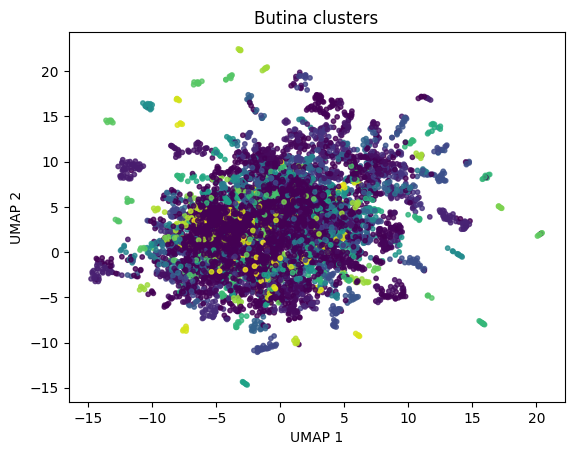

In [59]:
ax1 = plt.subplot(1, 1, 1)
ax1.scatter(
    umap_emb[:,0], 
    umap_emb[:,1],
    c=butina_labels,
    cmap="viridis",
    s=10,
    alpha=0.8
)
ax1.set(xlabel ="UMAP 1", ylabel="UMAP 2")
ax1.set_title("Butina clusters")


#### 9) Discussion points
1) How did the scaffolds and functional groups perform in the model performance in comparison the molecular descriptors? Comment on possible reasons. Which combination was suited best?

Functional group descriptors usually perform best, as they capture physicochemical properties such as LogP. Scaffold descriptors alone often contain too little data with too many unique values. The combination of both is typically best as it combines global properties with local reactivity

2) Is the One-Hot Encoding needed in this case?

It is not strictly required for random forests, but it is essential for linear models or neural networks to interpret categorical structural data (such as scaffolds or functional groups) as numerical inputs

3) Did the feature filtering (variance, correlation) have an improving effect? Explain!

The feature filtering improved efficiency and interpretability, by removing highly correlated features, which reduces overfitting by neglecting redundant data

4) Consider to make this kind of workflow for feature comparison more generally usable: How would a clean solution look? How could you ensure 
compatibility with other models? How would the function / pipeline look schematically?

Possible to use Scikit-learn Pipelines: [SMILES] --> [RDKit Transformer] --> [Feature Selector] --> [Scaler] --> [Model]

5) Visualisation: Using the scaffold fingerprints and the fingerprints for the entire molecule makes a huge difference. What is reason for this effect? Discuss this approach in contrast to similarity thresholds in the Butina clustering.

Entire-molecule fingerprints tent to show similarities (different scaffold, but similar side chains or func. groups). Scaffold fingerprints on the other hand, as the name suggests, groups molecules based on their scaffold (= core backbone of the structure). This appraoch is more rigid than Butina clustering, which only provides a rough similarity threshold

6) When might scaffolding prove useful?

Crucial for "scaffold hopping" (=finding scaffolds with the same/similar effect), which is important for drucg discovery or effectivity enhancement, but also something rather trivial as patent claims. Additionally, it helps identifying if toxicity is inherent to the molecule backbone or is caused by a removable side group (important for metabolite analysis)

7) Is toxicity correlated to molecular structure? I.e. what did the toxicity map in UMAP space reveal?

The toxicity map realts, that indeed structure and toxicity are correlated. The UMAP shows clusters where similar structures have similar toxicity, with the addition of specific points where a tiny structural change has a dramitic impact on toxicity